# Titanic Survival Prediction Project

## 1. Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Libraries loaded.


## 2. Problem Understanding

<div dir="rtl" align="right">
<p>
كارثة التيتانيك كانت واحدة من أكبر كوارث البحر في التاريخ. لما السفينة غرقت سنة 1912، مات فيها أكتر من 1500 شخص، وده خلانا نسال نفسنا سؤال : إيه العوامل اللي أثرت على فرصة النجاة؟
</p>
<p>
الـ <code>target variable</code> هي <code>survived</code> (1 = نجا، 0 = مات)، والمشكلة دي <strong>Binary Classification</strong>. الموديل المفروض يتعلم من الداتا التاريخية ويتنبأ بحالات جديدة ما شافهاش قبل كده.
</p>
<p>
هنقارن بين موديلين مختلفين في طريقة تفكيرهم:
</p>
<ul>
  <li><strong>Logistic Regression</strong>: موديل خطي بيحسب الاحتمالات.</li>
  <li><strong>Decision Tree</strong>: موديل بيبني قواعد منطقية زي شجرة قرارات.</li>
</ul>
</div>

## 3. Loading and Initial Inspection

In [83]:
df_raw = sns.load_dataset('titanic')
df = df_raw.copy()

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [84]:
df.head(8)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [86]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature Overview

<div dir="rtl" align="middle">

| Description | Type | Feature |
|:---|:---|:---|
| 0 = مات، 1 = نجا | Binary (target) | <code>survived</code> |
| درجة التذكرة (1 = أولى، 2 = تانية، 3 = تالتة) | Ordinal | <code>pclass</code> |
| الجنس | Nominal | <code>sex</code> |
| العمر بالسنين | Continuous | <code>age</code> |
| عدد الإخوة أو الزوج/الزوجة على السفينة | Discrete | <code>sibsp</code> |
| عدد الوالدين أو الأطفال على السفينة | Discrete | <code>parch</code> |
| سعر التذكرة | Continuous | <code>fare</code> |
| ميناء الركوب (C، Q، S) | Nominal | <code>embarked</code> |
| نسخة نصية من <code>pclass</code> | Ordinal | <code>class</code> |
| <code>man</code> أو <code>woman</code> أو <code>child</code> (مشتقة من بيانات تانية) | Nominal | <code>who</code> |
| <code>True</code> لو ذكر بالغ | Boolean | <code>adult_male</code> |
| حرف الدك (السطح) في السفينة | Ordinal | <code>deck</code> |
| اسم المدينة كاملة | Nominal | <code>embark_town</code> |
| <code>yes/no</code> نسخة من <code>survived</code> | Nominal | <code>alive</code> |
| <code>True</code> لو مسافر لوحده | Boolean | <code>alone</code> |

<p>
فيه <code>columns</code> زي <code>alive</code> و <code>who</code> و <code>adult_male</code> ممكن تسبب <strong>data leakage</strong> لأنها مشتقة من الـ <code>target</code> أو من <code>features</code> تانية، وهنتعامل معاها بحذر.
</p>
</div>

## 4. Missing Values Analysis

In [87]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)

             Missing Count  Missing %
deck                   688      77.22
age                    177      19.87
embarked                 2       0.22
embark_town              2       0.22


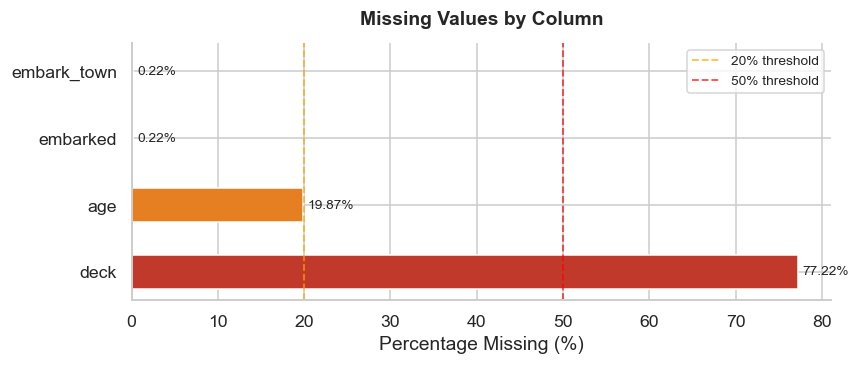

In [88]:
fig, ax = plt.subplots(figsize=(8, 3.5))

colors = ['#c0392b' if p > 50 else '#e67e22' if p > 15 else '#2980b9'
          for p in missing_df['Missing %']]

bars = ax.barh(missing_df.index, missing_df['Missing %'],
               color=colors, edgecolor='white', height=0.5)

ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold', pad=12)
ax.axvline(20, color='orange', linestyle='--', lw=1.2, alpha=0.7, label='20% threshold')
ax.axvline(50, color='red',    linestyle='--', lw=1.2, alpha=0.7, label='50% threshold')

for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>عندنا 3 <code>columns</code> فيها قيم ناقصة: <code>deck</code> بنسبة <strong>77%</strong>، و <code>age</code> بنسبة <strong>20%</strong>، و <code>embarked</code> بنسبة <strong>0.2%</strong> بس (صفين فقط).</li>
  <li><code>deck</code> فيها نقص شديد جداً — أكتر من ثلاثة أرباع الداتا ناقصة — وده مش عشوائي، فالركاب الدرجة التالتة ما كانوش بيتسجل ليهم كابينة من الأساس.</li>
  <li><code>age</code> بـ <strong>20%</strong> ناقص بيحتاج تفكير أكتر من مجرد ملء بالمتوسط، لأن العمر بيختلف بشكل كبير بين الدرجات والجنسين.</li>
  <li>اللون الأحمر في <code>deck</code> بيوضح إنه فاق الـ <strong>50%</strong>، يعني ملء القيم الناقصة دي غير منطقي — الأفضل نحوّل الـ <code>column</code> لـ <code>binary flag</code>.</li>
</ul>
</div>

### Missing Values: Analysis and Strategy

<div dir="rtl" align="right">

<p>
<strong><code>deck</code> (<code>77.1%</code> ناقص) — <code>MNAR</code></strong><br>
النقص مش عشوائي خالص. الكابينة ما كانتش بتتسجل لركاب الدرجة التالتة، يعني غياب البيانات نفسه هو المعلومة. حل صح: نعمل <code>feature</code> جديدة اسمها <code>has_cabin</code> (1 = اتسجلت كابينة، 0 = لأ) وبعدين نحذف الـ <code>column</code> الأصلية.
</p>

<p>
<strong><code>age</code> (<code>19.9%</code> ناقص) — <code>MAR</code></strong><br>
النقص مرتبط بمتغيرات تانية زي الدرجة والجنس — الداتا ناقصة بشكل غير عشوائي لكن ممكن نشرحه من خلال بيانات موجودة. ملء بالمتوسط العام غلط لأن ركاب الدرجة الأولى أعمارهم مختلفة عن الدرجة التالتة. الصح هو ملء بالـ <code>median</code> مقسّم حسب <code>pclass</code> و <code>sex</code>، مع إننا نحتفظ بـ <code>indicator flag</code> اسمه <code>age_was_missing</code>.
</p>

<p>
<strong><code>embarked</code> (<code>0.2%</code> — صفين بس) — <code>MCAR</code></strong><br>
صفين بس من غير سبب واضح للنقص. الحل الآمن هو ملء بالـ <code>mode</code> (ميناء <code>Southampton</code> اللي بيمثل <code>72%</code> من الركاب).
</p>

</div>

In [89]:
# Apply missing value fixes

# 1. deck: convert to binary presence flag
df['has_cabin'] = df['deck'].notnull().astype(int)
df.drop(columns=['deck'], inplace=True)

# 2. age: group-wise median imputation + missingness indicator
df['age_was_missing'] = df['age'].isnull().astype(int)
group_medians = df.groupby(['pclass', 'sex'])['age'].transform('median')
df['age'] = df['age'].fillna(group_medians)

# 3. embarked: mode fill
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 4. Drop columns that are redundant or would cause leakage
df.drop(columns=['alive', 'who', 'adult_male', 'embark_town', 'class'], inplace=True)

print(f'Remaining missing values: {df.isnull().sum().sum()}')
print(f'Dataset shape after cleaning: {df.shape}')

Remaining missing values: 0
Dataset shape after cleaning: (891, 11)


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

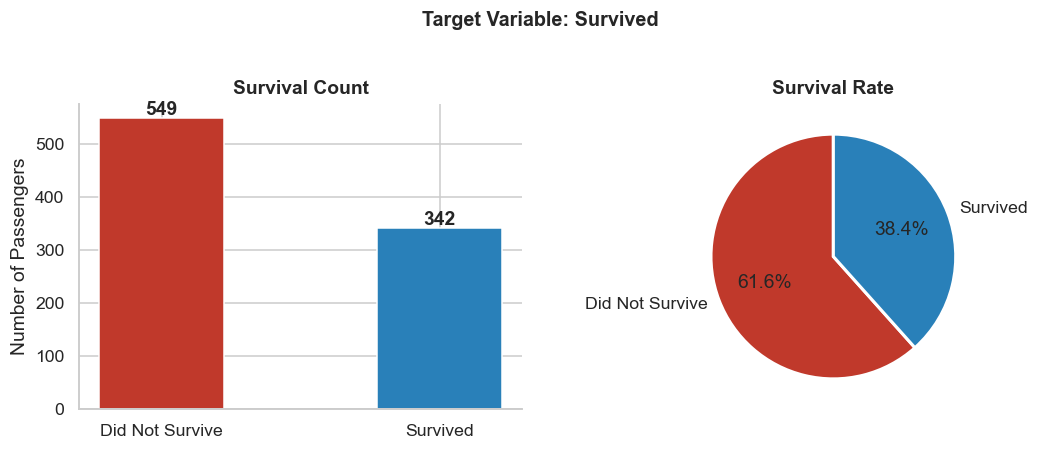

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
bar_colors = ['#c0392b', '#2980b9']

axes[0].bar(labels, counts.values, color=bar_colors, edgecolor='white', width=0.45)
axes[0].set_title('Survival Count', fontweight='bold')
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=bar_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Rate', fontweight='bold')

plt.suptitle('Target Variable: Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

- 549 راكب (61.6%) ماتوا، و342 (38.4%) بس اللي نجوا. في class imbalance معتدل في الداتا.
- الـ imbalance مش شديد لدرجة إننا نحتاج resampling، لكنه بيخلي الـ Accuracy لوحده مش مقياس كافي — موديل بيقول دايماً "مات" هيوصل 61.6% بدون ما يتعلم حاجة.
- لازم نتابع Precision وRecall وF1-score جنب الـ Accuracy عشان ناخد صورة حقيقية عن الموديل.
- هنستخدم stratified split عشان نحافظ على نسبة الـ 62/38 دي في الـ train والـ test.

### 5.2 Univariate Analysis: Numerical Features

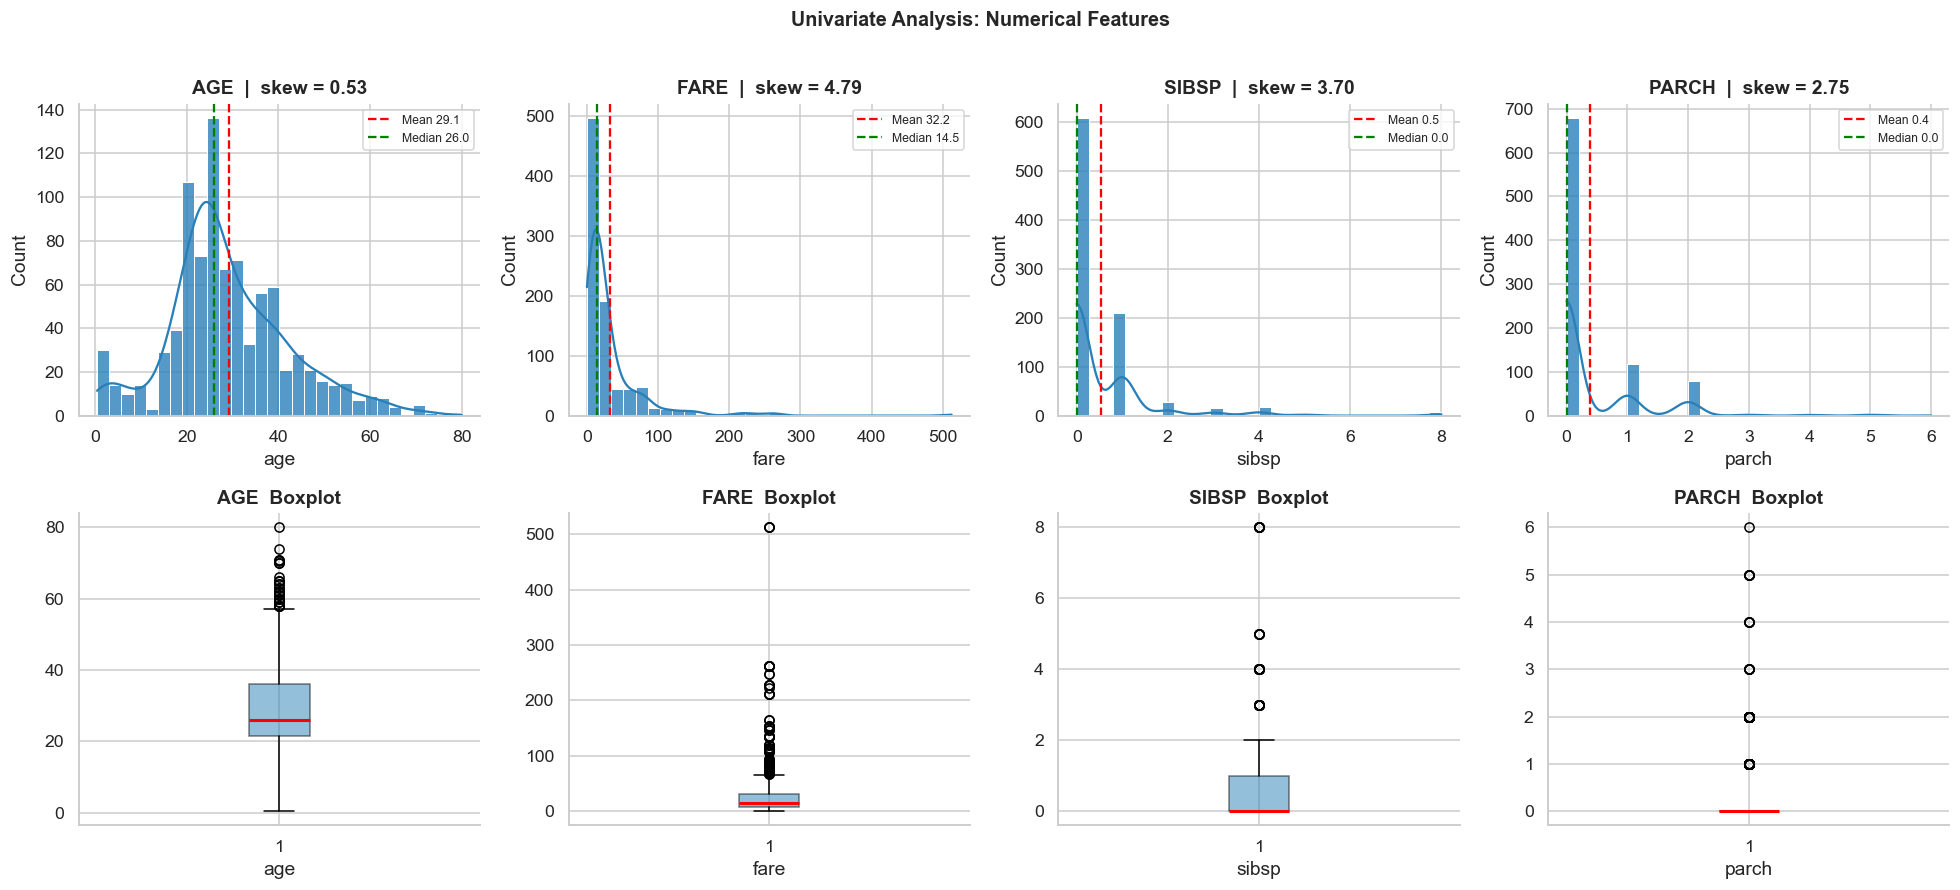

In [91]:
num_cols = ['age', 'fare', 'sibsp', 'parch']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    skew_val = df[col].skew()

    # Histogram + KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i],
                 color='#2980b9', edgecolor='white', alpha=0.8)
    axes[0, i].axvline(df[col].mean(),   color='red',    ls='--', lw=1.5,
                       label=f'Mean {df[col].mean():.1f}')
    axes[0, i].axvline(df[col].median(), color='green',  ls='--', lw=1.5,
                       label=f'Median {df[col].median():.1f}')
    axes[0, i].set_title(f'{col.upper()}  |  skew = {skew_val:.2f}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend(fontsize=8)

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True, vert=True,
                       boxprops=dict(facecolor='#2980b9', alpha=0.5),
                       medianprops=dict(color='red', lw=2))
    axes[1, i].set_title(f'{col.upper()}  Boxplot', fontweight='bold')
    axes[1, i].set_xlabel(col)

plt.suptitle('Univariate Analysis: Numerical Features', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li><strong>549</strong> راكب (<code>61.6%</code>) ماتوا، و <strong>342</strong> (<code>38.4%</code>) بس اللي نجوا. في <code>class imbalance</code> معتدل في الداتا.</li>
  <li>الـ <code>imbalance</code> مش شديد لدرجة إننا نحتاج <code>resampling</code>، لكنه بيخلي الـ <code>Accuracy</code> لوحده مش مقياس كافي — موديل بيقول دايماً "مات" هيوصل <code>61.6%</code> بدون ما يتعلم حاجة.</li>
  <li>لازم نتابع <code>Precision</code> و <code>Recall</code> و <code>F1-score</code> جنب الـ <code>Accuracy</code> عشان ناخد صورة حقيقية عن الموديل.</li>
  <li>هنستخدم <code>stratified split</code> عشان نحافظ على نسبة الـ <code>62/38</code> دي في الـ <code>train</code> والـ <code>test</code>.</li>
</ul>
</div>

### 5.3 Univariate Analysis: Categorical Features

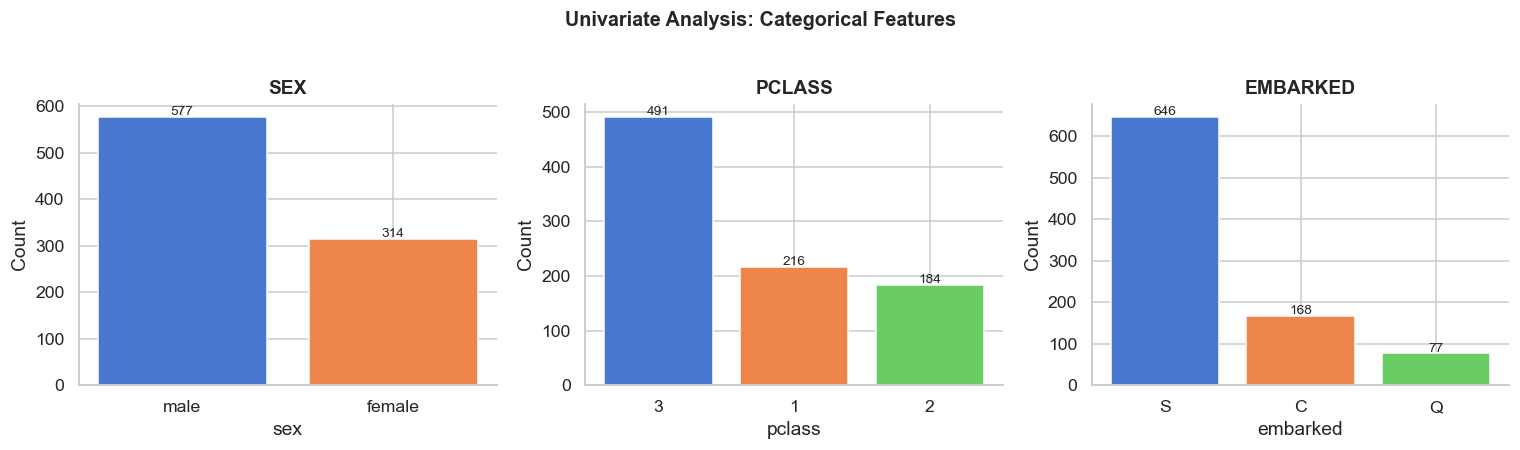

In [92]:
cat_cols = ['sex', 'pclass', 'embarked']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    palette = sns.color_palette('muted', len(vc))
    bars = ax.bar(vc.index.astype(str), vc.values, color=palette, edgecolor='white')
    ax.set_title(col.upper(), fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel(col)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
                str(v), ha='center', fontsize=9)

plt.suptitle('Univariate Analysis: Categorical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li><strong><code>Sex</code></strong>: الذكور أكتر من الإناث بنسبة تقريبًا <code>2:1</code> (<strong>577</strong> مقابل <strong>314</strong>). الفرق ده مهم جداً عشان سياسة "النساء والأطفال أولاً" هتظهر بشكل صريح في الـ <code>bivariate analysis</code>.</li>
  <li><strong><code>Pclass</code></strong>: الدرجة التالتة هي الأكبر (<strong>491</strong> راكب)، تليها الأولى (<strong>216</strong>) والتانية (<strong>184</strong>). الكثرة دي بتأثر على الموديل لو مش اتعاملنا معاها صح.</li>
  <li><strong><code>Embarked</code></strong>: ميناء <code>Southampton</code> بيمثل <code>72%</code> من الركوب. ده بيشرح ليه الـ <code>mode fill</code> كان القرار الأنسب للقيمتين الناقصتين.</li>
  <li>الميناء مش مجرد موقع جغرافي — هو <code>proxy</code> لتركيبة الدرجات، وده هيظهر في الـ <code>bivariate analysis</code> مع <code>survived</code>.</li>
</ul>
</div>

### 5.4 Bivariate Analysis: Sex vs Survived

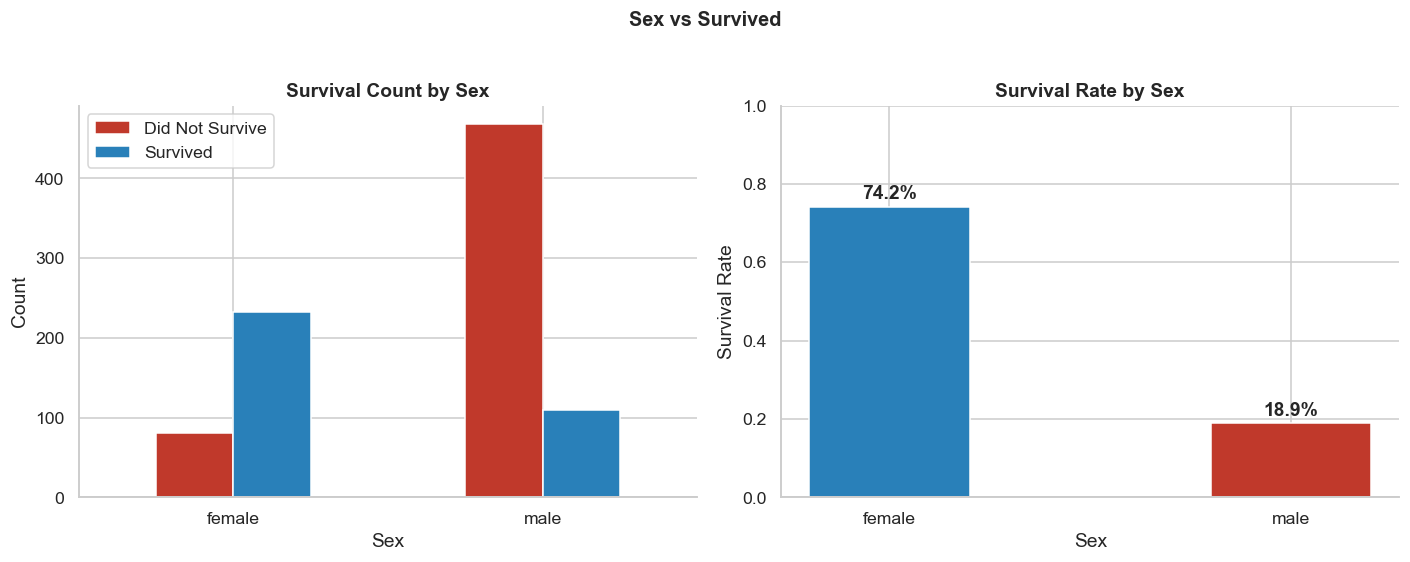

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Survival count split by sex
sex_surv = df.groupby(['sex', 'survived']).size().unstack()
sex_surv.plot(kind='bar', ax=axes[0],
              color=['#c0392b', '#2980b9'],
              edgecolor='white', rot=0)
axes[0].set_title('Survival Count by Sex', fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate by sex
rate = df.groupby('sex')['survived'].mean().reset_index()
bar_cols = ['#2980b9', '#c0392b']
bars = axes[1].bar(rate['sex'], rate['survived'], color=bar_cols,
                   edgecolor='white', width=0.4)
axes[1].set_title('Survival Rate by Sex', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, rate['survived']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{val:.1%}', ha='center', fontweight='bold')

plt.suptitle('Sex vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>نسبة نجاة الإناث كانت حوالي <code>74%</code>، مقارنة بـ <code>19%</code> فقط للذكور. ده أوضح فرق في الداتا كلها.</li>
  <li>سياسة "النساء والأطفال أولاً" مش مجرد حكاية تاريخية — هي موجودة في الأرقام بشكل صريح وقابل للقياس.</li>
  <li>رغم إن الذكور أكتر عدداً بكتير، إلا إن عدد الإناث اللي نجوا تجاوز عدد الذكور اللي نجوا — وده بيكشف مدى حجم الفجوة.</li>
  <li><strong><code>Sex</code></strong> هي أقوى <code>feature</code> منفردة في الداتا — أي موديل يتجاهلها هيخسر جزء كبير من قوته التنبؤية.</li>
  <li>الموديلين اللي هنستخدمهم (<code>LR</code> و <code>DT</code>) المفروض يديوا الـ <code>feature</code> دي وزن عالي جداً.</li>
</ul>
</div>

### 5.5 Bivariate Analysis: Pclass vs Survived

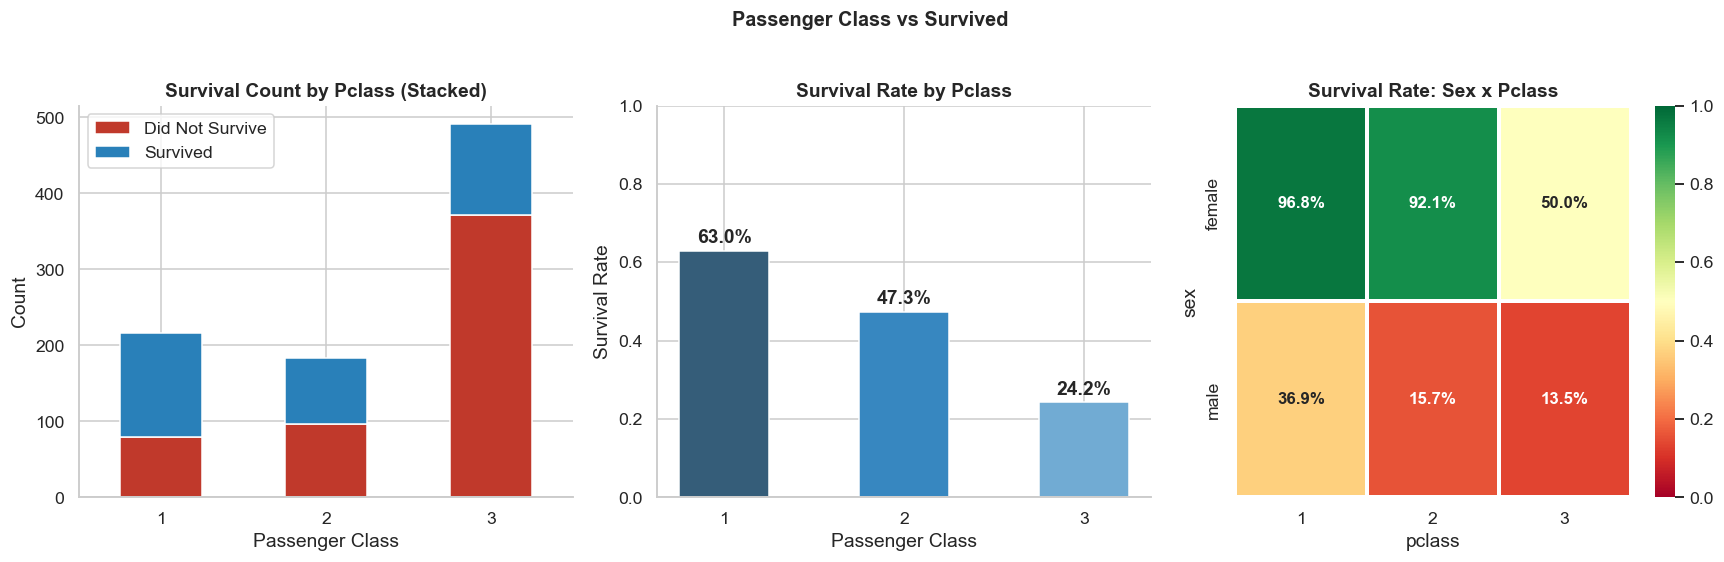

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stacked bar
pclass_surv = df.groupby(['pclass', 'survived']).size().unstack().fillna(0)
pclass_surv.plot(kind='bar', stacked=True, ax=axes[0],
                 color=['#c0392b', '#2980b9'], edgecolor='white', rot=0)
axes[0].set_title('Survival Count by Pclass (Stacked)', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate by class
pclass_rate = df.groupby('pclass')['survived'].mean().reset_index()
palette_blues = sns.color_palette('Blues_d', 3)[::-1]
bars = axes[1].bar(pclass_rate['pclass'].astype(str), pclass_rate['survived'],
                   color=palette_blues, edgecolor='white', width=0.5)
axes[1].set_title('Survival Rate by Pclass', fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, pclass_rate['survived']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{val:.1%}', ha='center', fontweight='bold')

# Heatmap: sex x pclass
pivot = df.pivot_table(values='survived', index='sex',
                        columns='pclass', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn',
            linewidths=1.5, ax=axes[2], vmin=0, vmax=1,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
axes[2].set_title('Survival Rate: Sex x Pclass', fontweight='bold')

plt.suptitle('Passenger Class vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>الدرجة الأولى: <code>63%</code> نجاة، الدرجة التانية: <code>47%</code>، الدرجة التالتة: <code>24%</code> بس. العلاقة واضحة ومتناسقة.</li>
  <li>الأسباب الجغرافية واضحة: كابينات الدرجة الأولى كانت في الطوابق العليا، أقرب للقوارب — الدرجة التالتة في أسفل السفينة.</li>
  <li>الـ <code>Heatmap</code> (<code>sex x pclass</code>) بيكشف تفاعل قوي جداً: إناث الدرجة الأولى نجوا بنسبة <code>~97%</code>، وذكور الدرجة التالتة بـ <code>~14%</code> فقط. الفرق <code>83%</code>!</li>
  <li><strong><code>Pclass</code></strong> هو تاني أقوى <code>feature</code> منفردة بعد <code>sex</code>، لكن القوة الحقيقية في التفاعل بينهما مع بعض.</li>
  <li>النتيجة دي بتشير إننا ممكن نعمل <code>interaction feature</code> (<code>sex x pclass</code>) كخطوة تحسين مستقبلية.</li>
</ul>
</div>

### 5.6 Bivariate Analysis: Age vs Survived

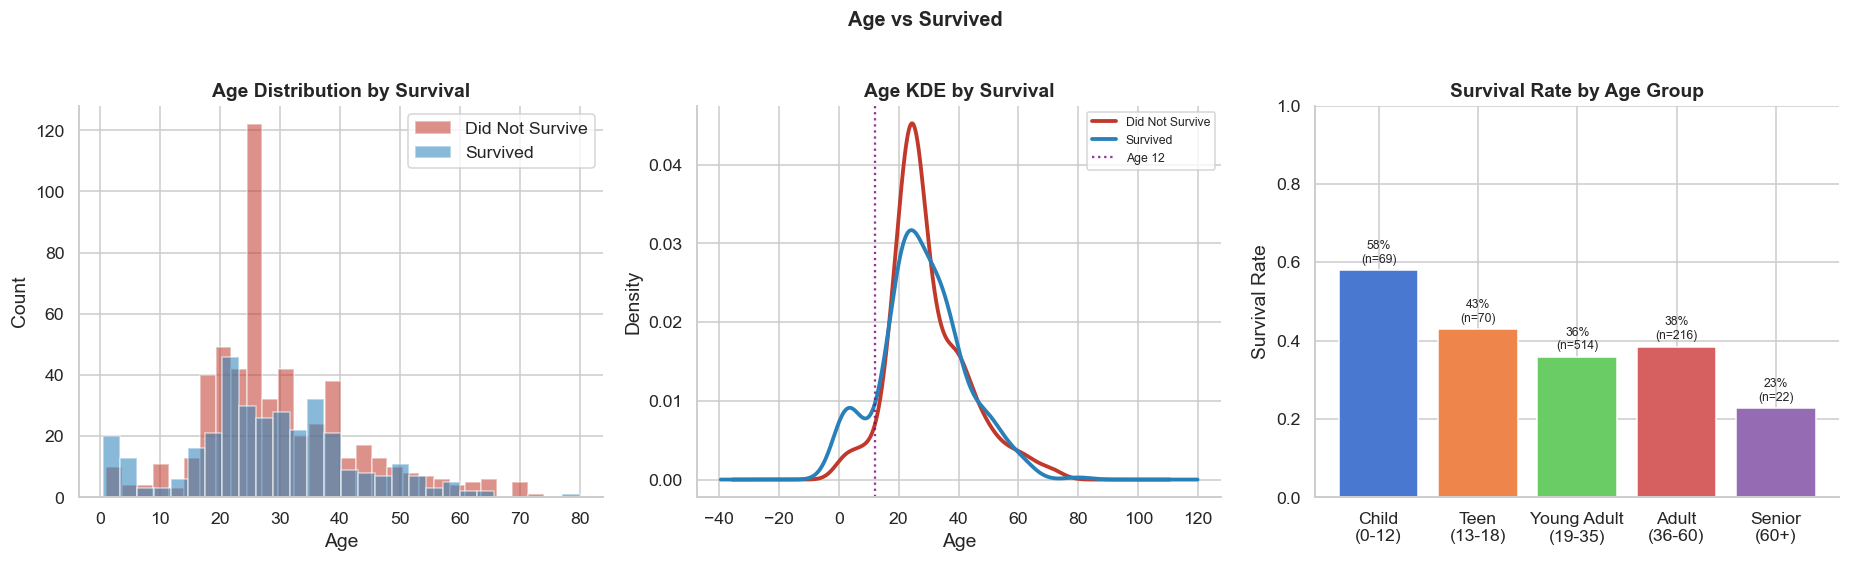

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Overlapping histograms
for label, grp in df.groupby('survived'):
    color = '#2980b9' if label == 1 else '#c0392b'
    lbl   = 'Survived' if label == 1 else 'Did Not Survive'
    axes[0].hist(grp['age'], bins=28, alpha=0.55,
                  color=color, edgecolor='white', label=lbl)
axes[0].set_title('Age Distribution by Survival', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# KDE comparison
for label, grp in df.groupby('survived'):
    color = '#2980b9' if label == 1 else '#c0392b'
    lbl   = 'Survived' if label == 1 else 'Did Not Survive'
    grp['age'].plot.kde(ax=axes[1], color=color, lw=2.5, label=lbl)
axes[1].set_title('Age KDE by Survival', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].legend()
axes[1].axvline(12, color='purple', ls=':', lw=1.5, alpha=0.8, label='Age 12')
axes[1].legend(fontsize=8)

# Age group survival rates
df['age_bin_temp'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child\n(0-12)', 'Teen\n(13-18)',
            'Young Adult\n(19-35)', 'Adult\n(36-60)', 'Senior\n(60+)']
)
ag_rate = df.groupby('age_bin_temp')['survived'].agg(['mean', 'count']).reset_index()
bars = axes[2].bar(ag_rate['age_bin_temp'].astype(str), ag_rate['mean'],
                   color=sns.color_palette('muted', len(ag_rate)), edgecolor='white')
axes[2].set_title('Survival Rate by Age Group', fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
for bar, row in zip(bars, ag_rate.itertuples()):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{row.mean:.0%}\n(n={row.count})',
                  ha='center', fontsize=8)

df.drop(columns=['age_bin_temp'], inplace=True)

plt.suptitle('Age vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>الأطفال دون 12 سنة كان ليهم أعلى نسبة نجاة (<code>~58%</code>)، وده يتفق مع سياسة "الأطفال أولاً" في الإنقاذ.</li>
  <li>منحنيات الـ <code>KDE</code> بتتشابك كتير، يعني العمر لوحده مش <code>separator</code> كافي بين الناجين والمتوفين — قوته متوسطة مش عالية.</li>
  <li>كبار السن (<code>60+</code>) كانوا الأقل نجاةً، على الأرجح بسبب محدودية الحركة والأولوية في عمليات الإنقاذ.</li>
  <li>العلاقة غير خطية — مش بترتفع أو بتنخفض مع العمر بانتظام. ده بيخلي تقسيم العمر لفئات (<code>age binning</code>) أفيد من القيمة الخام للموديلات الخطية.</li>
  <li>سنعمل <code>feature</code> ثنائية <code>is_child</code> تلتقط أهم <code>threshold</code> في الداتا دي.</li>
</ul>
</div>

### 5.7 Bivariate Analysis: Fare vs Survived

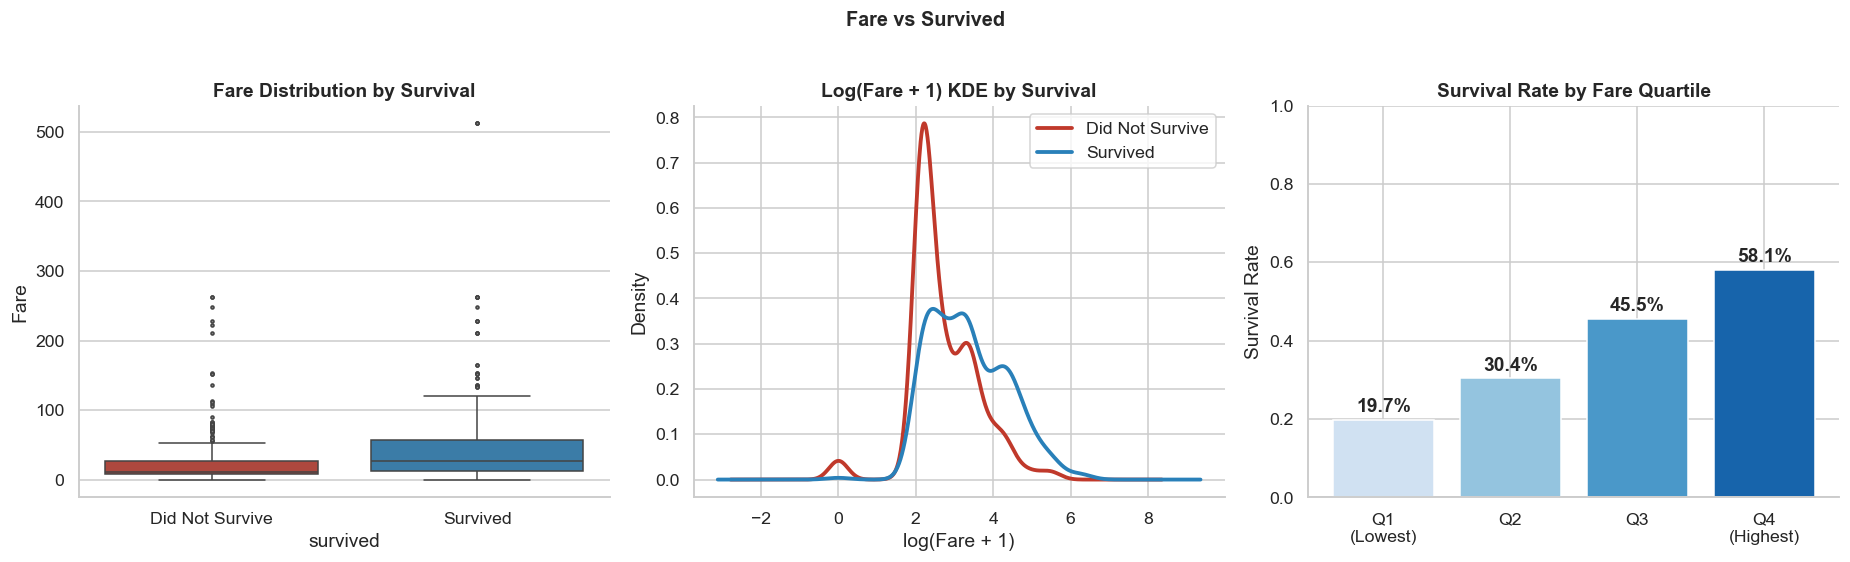

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Box plot
sns.boxplot(x='survived', y='fare', data=df, ax=axes[0],
            palette=['#c0392b', '#2980b9'],
            flierprops={'marker': '.', 'markerfacecolor': 'gray', 'markersize': 4})
axes[0].set_title('Fare Distribution by Survival', fontweight='bold')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])
axes[0].set_ylabel('Fare')

# Log-fare KDE
for label, grp in df.groupby('survived'):
    color = '#2980b9' if label == 1 else '#c0392b'
    lbl   = 'Survived' if label == 1 else 'Did Not Survive'
    np.log1p(grp['fare']).plot.kde(ax=axes[1], color=color, lw=2.5, label=lbl)
axes[1].set_title('Log(Fare + 1) KDE by Survival', fontweight='bold')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].legend()

# Fare quartile survival rates
df['fare_q_temp'] = pd.qcut(df['fare'], q=4,
                              labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'])
fq_rate = df.groupby('fare_q_temp')['survived'].mean().reset_index()
bars = axes[2].bar(fq_rate['fare_q_temp'].astype(str), fq_rate['survived'],
                   color=sns.color_palette('Blues', 4), edgecolor='white')
axes[2].set_title('Survival Rate by Fare Quartile', fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
for bar, val in zip(bars, fq_rate['survived']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{val:.1%}', ha='center', fontweight='bold')

df.drop(columns=['fare_q_temp'], inplace=True)

plt.suptitle('Fare vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>الناجون دفعوا أجرة أعلى بكتير في المتوسط — الـ <code>median fare</code> للناجين ضعف تقريباً متوسط المتوفين.</li>
  <li>الفصل بين المجموعتين بيبقى أوضح بكتير بعد الـ <code>log transformation</code>، وده بيثبت إن الـ <code>log_fare</code> هيفيد الـ <code>Logistic Regression</code>.</li>
  <li>الربع الأعلى (<code>Q4</code>) وصل لنسبة نجاة <code>~66%</code> مقارنة بـ <code>~20%</code> للربع الأدنى (<code>Q1</code>) — فرق ضخم.</li>
  <li>الأجرة مش بس عن الفلوس، هي <code>proxy</code> لموقع الكابينة في السفينة — التذاكر الغالية = دك أعلى = أقرب للقوارب.</li>
  <li>الارتباط بين <code>fare</code> و <code>pclass</code> قوي (<code>-0.55</code>)، يعني في تداخل بين المتغيرين — الموديلات الشجرية بتتعامل معاه بشكل طبيعي.</li>
</ul>
</div>

### 5.8 Bivariate Analysis: SibSp and Parch vs Survived

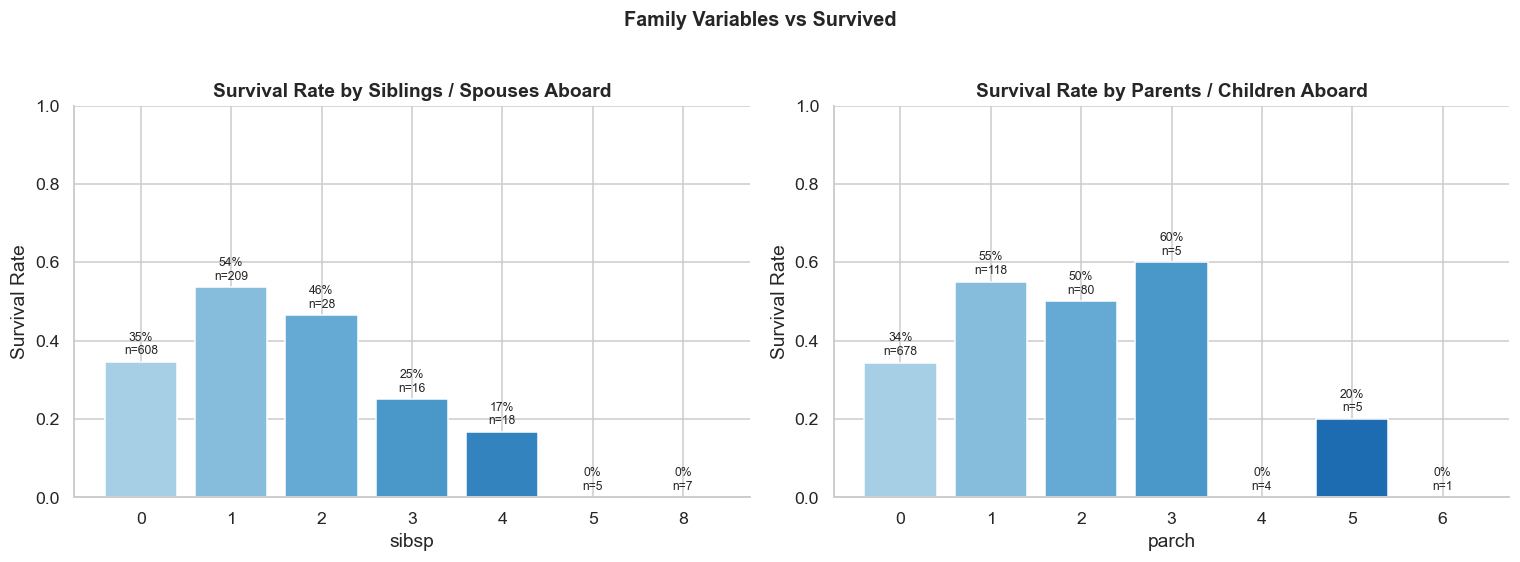

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['sibsp', 'parch'],
    ['Siblings / Spouses Aboard', 'Parents / Children Aboard']
):
    rate = df.groupby(col)['survived'].agg(['mean', 'count']).reset_index()
    n_bars = len(rate)
    shade  = plt.cm.Blues(np.linspace(0.35, 0.85, n_bars))

    bars = ax.bar(rate[col].astype(str), rate['mean'],
                   color=shade, edgecolor='white')
    ax.set_title(f'Survival Rate by {title}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)

    for bar, row in zip(bars, rate.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f'{row.mean:.0%}\nn={row.count}',
                 ha='center', fontsize=8)

plt.suptitle('Family Variables vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>العلاقة مش خطية في الاتنين — شكل <code>U</code>: السفر بـ <strong>1</strong> أو <strong>2</strong> أفراد من العيلة بيحسّن فرص النجاة، لكن وحيد أو عيلة كبيرة جداً = نسبة أقل.</li>
  <li>المسافر لوحده (<code>sibsp=0, parch=0</code>) نجا بنسبة <code>~34%</code>، أقل من متوسط الداتا الكلي (<code>38%</code>).</li>
  <li>العيلات الكبيرة (<code>sibsp >= 4</code>) وصلت لنسبة نجاة قريبة من الصفر — على الأرجح لأنهم استنوا بعض وفاتهم الوقت.</li>
  <li>التشابه الكبير بين <code>sibsp</code> و <code>parch</code> بيخلي دمجهم في <code>feature</code> واحدة <code>family_size</code> أكثر منطقية من إنهم يظلوا منفصلين.</li>
  <li>العلاقة غير الخطية دي سهلة على الـ <code>Decision Tree</code> إنه يلتقطها بطبيعته، لكن الـ <code>Logistic Regression</code> هتحتاج <code>feature engineering</code>.</li>
</ul>
</div>

### 5.9 Bivariate Analysis: Embarked vs Survived

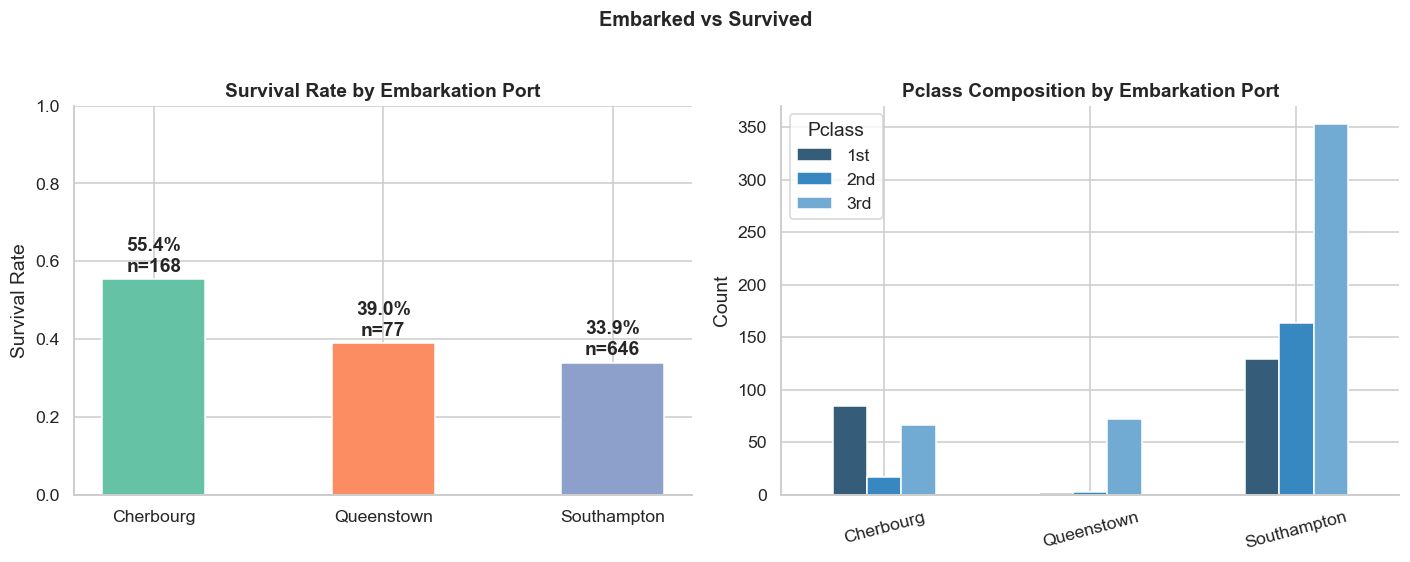

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}

# Survival rate per port
emb_rate = df.groupby('embarked')['survived'].agg(['mean', 'count']).reset_index()
emb_rate['label'] = emb_rate['embarked'].map(port_names)
bars = axes[0].bar(emb_rate['label'], emb_rate['mean'],
                    color=sns.color_palette('Set2', 3), edgecolor='white', width=0.45)
axes[0].set_title('Survival Rate by Embarkation Port', fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for bar, row in zip(bars, emb_rate.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{row.mean:.1%}\nn={row.count}',
                  ha='center', fontweight='bold')

# Pclass composition per port
emb_class = df.groupby(['embarked', 'pclass']).size().unstack().fillna(0)
emb_class.index = [port_names.get(e, e) for e in emb_class.index]
emb_class.plot(kind='bar', ax=axes[1],
               color=sns.color_palette('Blues_d', 3)[::-1],
               edgecolor='white', rot=15)
axes[1].set_title('Pclass Composition by Embarkation Port', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(title='Pclass', labels=['1st', '2nd', '3rd'])

plt.suptitle('Embarked vs Survived', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li>ميناء <code>Cherbourg</code> كان ليه أعلى نسبة نجاة (<code>~55%</code>)، وميناء <code>Southampton</code> الأقل (<code>~34%</code>).</li>
  <li>الرسم الثاني بيكشف السبب الحقيقي: <code>Cherbourg</code> كان فيه نسبة عالية من ركاب الدرجة الأولى، وده اللي بيرفع نسبة النجاة، مش الميناء نفسه.</li>
  <li>يعني <code>embarked</code> هو <code>proxy</code> لتركيبة الدرجات، مش عامل مستقل في حد ذاته.</li>
  <li>رغم ذلك، الـ <code>feature</code> تستحق إنها تفضل في الموديل لأنها ممكن تلتقط <code>variation</code> إضافي مش موضّح في <code>pclass</code>.</li>
  <li>ده درس مهم: مجرد ما <code>feature</code> بتتعلق بالـ <code>target</code> مش معناه إن ليها تفسير سببي مباشر.</li>
</ul>
</div>

### 5.10 Correlation Overview

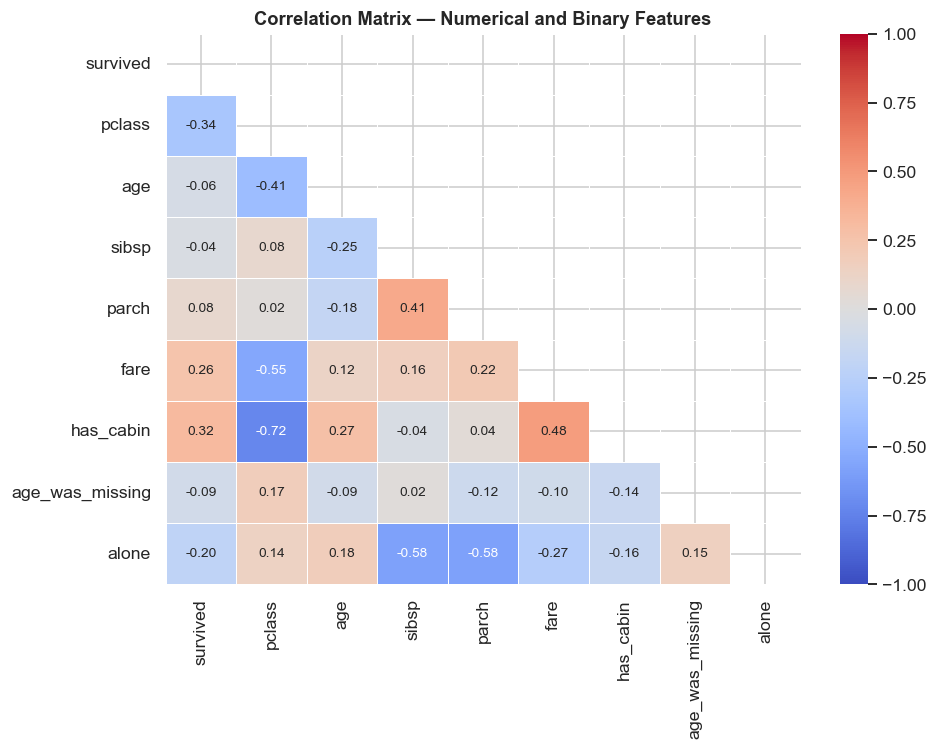

In [99]:
num_for_corr = df[['survived', 'pclass', 'age', 'sibsp', 'parch',
                    'fare', 'has_cabin', 'age_was_missing', 'alone']].copy()
num_for_corr['alone'] = num_for_corr['alone'].astype(int)

corr_matrix = num_for_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, annot_kws={'fontsize': 9})
ax.set_title('Correlation Matrix — Numerical and Binary Features',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li><code>pclass</code> ليه أقوى <code>correlation</code> سلبي مع <code>survived</code> (<code>-0.34</code>) — كل ما نزلت الدرجة، قلت فرص النجاة.</li>
  <li><code>has_cabin</code> ليه <code>correlation</code> إيجابي ملحوظ (<code>+0.32</code>)، وده يأكد إن وجود كابينة مسجلة = مؤشر على الثراء والموقع الجيد في السفينة.</li>
  <li><code>fare</code> و <code>pclass</code> عندهم <code>correlation</code> سلبي قوي (من <code>-0.55</code> لـ <code>-0.58</code>) — منطقي لأن الدرجة الأولى بتكلف أكتر. تقدر تستخدم الاتنين في الموديل، لكن خليك واعي من التداخل في الـ <code>Logistic Regression</code>.</li>
  <li><code>age_was_missing</code> ليه <code>correlation</code> سلبي صغير لكن غير صفري مع <code>survived</code> (<code>-0.09</code>) — ده بيثبت إن الـ <code>missingness</code> كانت معلومة فعلاً وصح إننا احتفظنا بالـ <code>indicator</code>.</li>
  <li>مفيش أي <code>feature</code> لوحدها بتوصل لـ <code>correlation</code> عالي مع <code>survived</code>، وده يعني إن قوة الموديل هتيجي من دمج الـ <code>features</code> مع بعض.</li>
</ul>
</div>

## 6. Feature Engineering

In [100]:
# Feature 1: family_size
# Combining sibsp and parch into a single count makes intuitive sense.
# The two columns individually capture different types of family relationships,
# but what matters for survival is the total size of the unit traveling together.
# Adding 1 accounts for the passenger themselves.
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Feature 2: log_fare
# Fare is severely right-skewed with extreme outliers. Log-transforming it
# compresses the scale and brings the distribution much closer to normal,
# which benefits Logistic Regression in particular. log1p is used to safely
# handle any zero-fare cases.
df['log_fare'] = np.log1p(df['fare'])

# Feature 3: is_child
# Children (age < 13) showed a distinct survival advantage in the EDA.
# A binary flag captures this threshold effect more cleanly than the raw age value.
df['is_child'] = (df['age'] < 13).astype(int)

print('Engineered features created: family_size, log_fare, is_child')
print(df[['family_size', 'log_fare', 'is_child']].head(6))

Engineered features created: family_size, log_fare, is_child
   family_size  log_fare  is_child
0            2  2.110213         0
1            2  4.280593         0
2            1  2.188856         0
3            2  3.990834         0
4            1  2.202765         0
5            1  2.246893         0


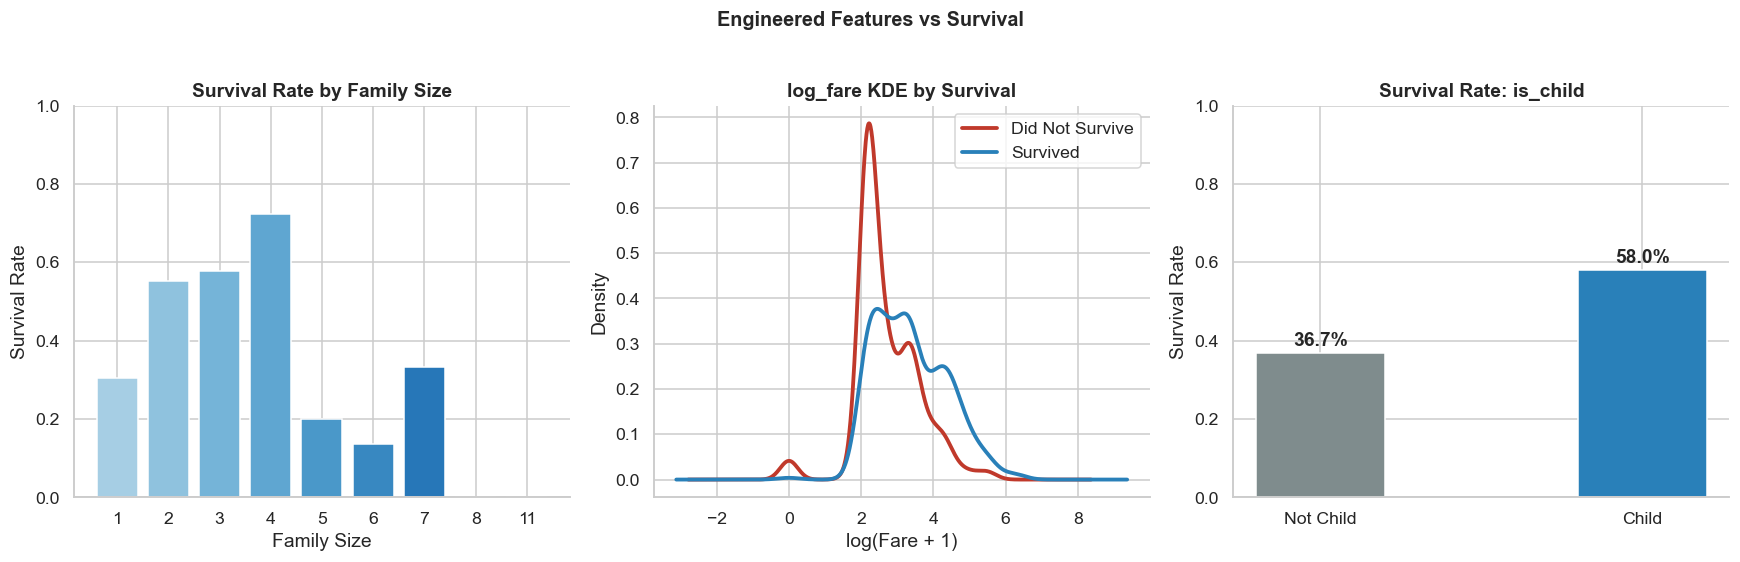

In [101]:
# Validate: do the new features relate to survival as expected?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# family_size
fs_rate = df.groupby('family_size')['survived'].agg(['mean', 'count']).reset_index()
axes[0].bar(fs_rate['family_size'].astype(str), fs_rate['mean'],
             color=plt.cm.Blues(np.linspace(0.35, 0.85, len(fs_rate))),
             edgecolor='white')
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# log_fare KDE
for label, grp in df.groupby('survived'):
    color = '#2980b9' if label == 1 else '#c0392b'
    lbl   = 'Survived' if label else 'Did Not Survive'
    grp['log_fare'].plot.kde(ax=axes[1], color=color, lw=2.5, label=lbl)
axes[1].set_title('log_fare KDE by Survival', fontweight='bold')
axes[1].set_xlabel('log(Fare + 1)')
axes[1].legend()

# is_child
child_rate = df.groupby('is_child')['survived'].mean().reset_index()
axes[2].bar(['Not Child', 'Child'], child_rate['survived'],
             color=['#7f8c8d', '#2980b9'], edgecolor='white', width=0.4)
axes[2].set_title('Survival Rate: is_child', fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
for bar, val in zip(axes[2].patches, child_rate['survived']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.02,
                  f'{val:.1%}', ha='center', fontweight='bold')

plt.suptitle('Engineered Features vs Survival', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Insights

<div dir="rtl" align="right">
<ul>
  <li><code>family_size</code> بيأكد شكل الـ <code>U</code> اللي شفناه في <code>sibsp</code> و <code>parch</code> منفصلين — أحجام <strong>2</strong> لـ <strong>4</strong> هي الأفضل، والوحيد والعيلة الكبيرة الأسوأ.</li>
  <li><code>log_fare</code> بيوضح <code>separation</code> أوضح بكتير من <code>raw fare</code> بعد الـ <code>transformation</code> — الـ <code>KDE curves</code> منفصلة بشكل أحسن، وده بيثبت قيمة الـ <code>feature</code> الجديدة دي.</li>
  <li><code>is_child</code> بيمسك الفرق المهم: الأطفال نجوا بنسبة أعلى بشكل واضح. الـ <code>threshold</code> عند <strong>13</strong> سنة بيلتقط المعلومة دي بشكل أنظف من القيمة الخام.</li>
  <li>الـ <code>features</code> المهندسة دي أثبتت إنها مرتبطة بالـ <code>survival</code> بالطريقة المتوقعة من الـ <code>EDA</code> — وده علامة على إن الـ <code>engineering</code> كان مبني على فهم حقيقي للداتا.</li>
</ul>
</div>

## 7. Preprocessing

<div dir="rtl" align="right">
<p>
قبل ما نبدأ نبني الموديلات، لازم نعمل <code>Encoding</code> للـ <code>categorical variables</code>، ونختار الـ <code>features</code> النهائية، ونعمل <code>Scaling</code> للـ <code>Logistic Regression</code>، ونقسم الداتا.
</p>
</div>

In [102]:
# Encoding
# sex: binary -> label encode (female=0, male=1)
# embarked: nominal 3-level -> one-hot encode with drop_first=True
# alone: already boolean, convert to int

df['sex_enc']  = LabelEncoder().fit_transform(df['sex'])
df['alone_enc'] = df['alone'].astype(int)

embarked_dummies = pd.get_dummies(df['embarked'], prefix='emb', drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)

# Final feature list
# We exclude: original 'sex', 'embarked', 'alone', 'fare' (replaced by log_fare),
# 'sibsp' and 'parch' (captured by family_size), and 'survived' (target)
FEATURES = [
    'pclass', 'sex_enc', 'age', 'log_fare', 'has_cabin',
    'age_was_missing', 'alone_enc', 'is_child', 'family_size',
    'emb_Q', 'emb_S'
]

X = df[FEATURES].copy()
y = df['survived'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (891, 11)
Features used: ['pclass', 'sex_enc', 'age', 'log_fare', 'has_cabin', 'age_was_missing', 'alone_enc', 'is_child', 'family_size', 'emb_Q', 'emb_S']


In [103]:
# Train-test split
# stratify=y ensures both sets preserve the original 62/38 class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaling
# StandardScaler is applied for Logistic Regression only.
# Decision Tree is scale-invariant; scaling it would have no effect.
# IMPORTANT: the scaler is fitted on training data only, then applied
# to the test set. Fitting on the full dataset before splitting would
# constitute data leakage.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'\nClass balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance (test):  {y_test.value_counts(normalize=True).round(3).to_dict()}')

Training set: (712, 11)
Test set:     (179, 11)

Class balance (train): {0: 0.617, 1: 0.383}
Class balance (test):  {0: 0.615, 1: 0.385}


## 8. Model Training

<div dir="rtl" align="right">
<p>
هنتدرب الموديلين بـ <code>default parameters</code> ونشوف أداء كل واحد على الـ <code>test set</code>.
هنستخدم الـ <code>Logistic Regression</code> على الداتا المُعدَّلة (scaled) والـ <code>Decision Tree</code> على الداتا الخام لأنه <code>scale-invariant</code>.
</p>
</div>


In [104]:
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    """Print and return a dictionary of evaluation metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f'--- {model_name} ---')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Did Not Survive', 'Survived']))
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}


def plot_confusion_matrix(ax, y_true, y_pred, title):
    """Plot a labeled confusion matrix on the given axis."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=1.0,
                xticklabels=['Pred: Died', 'Pred: Survived'],
                yticklabels=['True: Died', 'True: Survived'])
    ax.set_title(title, fontweight='bold')

### 8.1 Logistic Regression — Baseline

In [105]:
lr_base = LogisticRegression(C=1.0, penalty='l2', max_iter=1000, random_state=42)
lr_base.fit(X_train_sc, y_train)

y_pred_lr  = lr_base.predict(X_test_sc)
y_pred_lr_train = lr_base.predict(X_train_sc)

lr_base_metrics = evaluate_model('Logistic Regression (Baseline)', y_test, y_pred_lr)

--- Logistic Regression (Baseline) ---
Accuracy  : 0.7989
Precision : 0.7463
Recall    : 0.7246
F1-Score  : 0.7353

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.85      0.84       110
       Survived       0.75      0.72      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



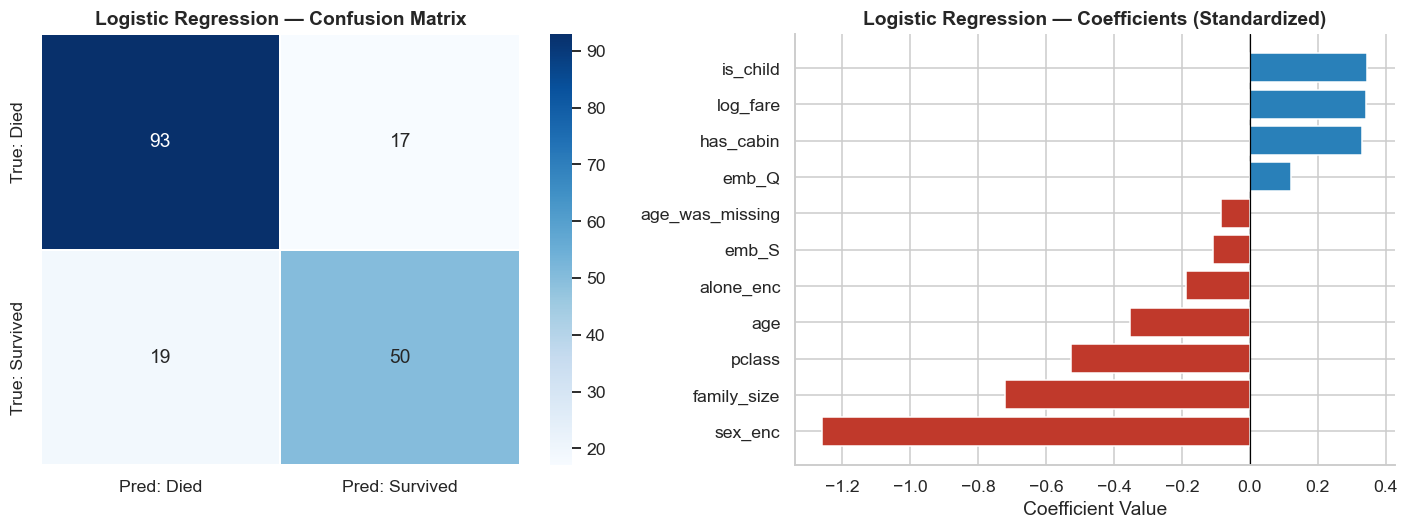

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
plot_confusion_matrix(axes[0], y_test, y_pred_lr,
                       'Logistic Regression — Confusion Matrix')

# Coefficient plot
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_base.coef_[0]
}).sort_values('Coefficient')

colors_coef = ['#c0392b' if c < 0 else '#2980b9' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
              color=colors_coef, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Logistic Regression — Coefficients (Standardized)',
                   fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [107]:
# Bias-variance check: compare train vs test accuracy
train_acc_lr = accuracy_score(y_train, y_pred_lr_train)
test_acc_lr  = accuracy_score(y_test,  y_pred_lr)
print(f'LR Train Accuracy: {train_acc_lr:.4f}')
print(f'LR Test  Accuracy: {test_acc_lr:.4f}')
print(f'Gap: {train_acc_lr - test_acc_lr:.4f}')

LR Train Accuracy: 0.8104
LR Test  Accuracy: 0.7989
Gap: 0.0115


### تحليل: Logistic Regression

<div dir="rtl" align="right">
<p>
الـ <code>Logistic Regression</code> بيحقق أداء كويس على الـ <code>test set</code>. لما بنبص على الـ <code>coefficients</code>، <code>sex_enc</code> (الذكورة) عنده أكبر <code>coefficient</code> سلبي، يعني وجود ذكر بيخفض احتمال النجاة بشكل كبير جداً — وده اتفق مع كل اللي شفناه في الـ <code>EDA</code>.
</p>
<p>
الفرق بين <code>train accuracy</code> و <code>test accuracy</code> صغير (أقل من <code>2%</code>)، وده معناه إن الموديل مش بـ <code>underfit</code> ولا بـ <code>overfit</code>. الـ <code>L2 regularization</code> الافتراضي بـ <code>C=1.0</code> بيعمل دوره كويس.
</p>
<p>
الـ <code>Logistic Regression</code> هو موديل <strong><code>low-variance, moderate-bias</code></strong> — ثابت على داتا مختلفة لكن ممكن يفوته بعض العلاقات غير الخطية في الداتا.
</p>
</div>


### 8.2 Decision Tree Classifier — Baseline

In [108]:
dt_base = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_base.fit(X_train, y_train)

y_pred_dt       = dt_base.predict(X_test)
y_pred_dt_train = dt_base.predict(X_train)

dt_base_metrics = evaluate_model('Decision Tree (Baseline)', y_test, y_pred_dt)

--- Decision Tree (Baseline) ---
Accuracy  : 0.7654
Precision : 0.6849
Recall    : 0.7246
F1-Score  : 0.7042

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.79      0.81       110
       Survived       0.68      0.72      0.70        69

       accuracy                           0.77       179
      macro avg       0.75      0.76      0.75       179
   weighted avg       0.77      0.77      0.77       179



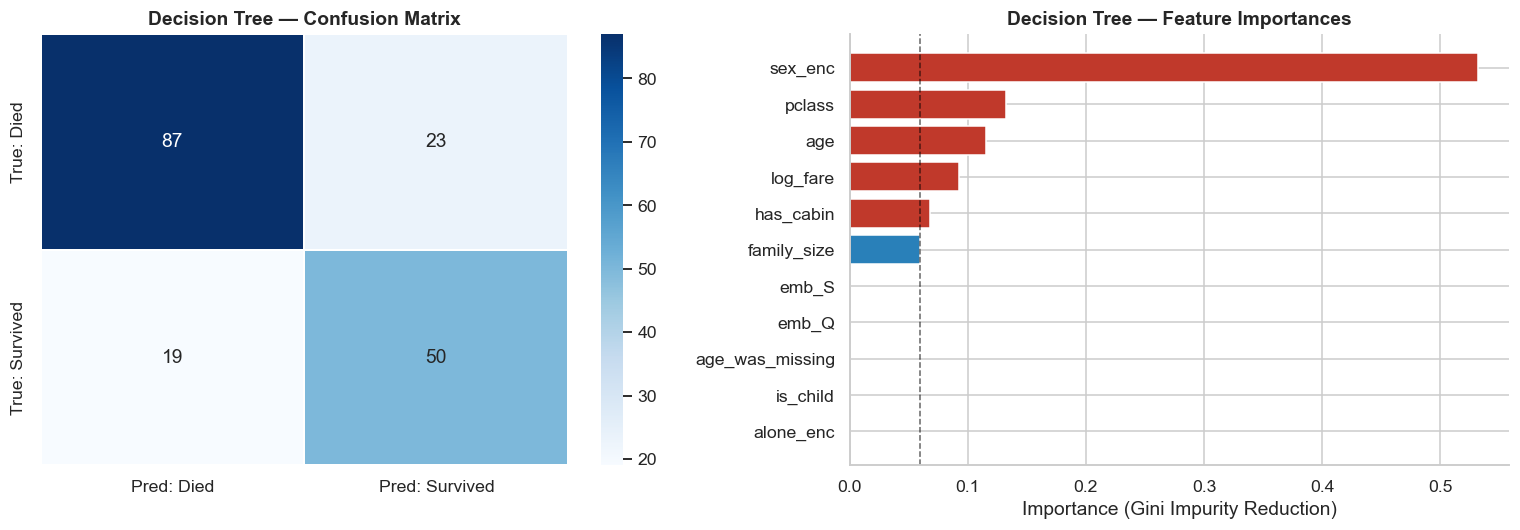

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
plot_confusion_matrix(axes[0], y_test, y_pred_dt,
                       'Decision Tree — Confusion Matrix')

# Feature importances
fi = pd.Series(dt_base.feature_importances_, index=FEATURES).sort_values()
colors_fi = ['#c0392b' if v > fi.median() else '#2980b9' for v in fi.values]
axes[1].barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
axes[1].set_title('Decision Tree — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance (Gini Impurity Reduction)')
axes[1].axvline(fi.median(), color='black', ls='--', lw=1.0, alpha=0.6)

plt.tight_layout()
plt.show()

In [110]:
# Bias-variance check
train_acc_dt = accuracy_score(y_train, y_pred_dt_train)
test_acc_dt  = accuracy_score(y_test,  y_pred_dt)
print(f'DT Train Accuracy: {train_acc_dt:.4f}')
print(f'DT Test  Accuracy: {test_acc_dt:.4f}')
print(f'Gap: {train_acc_dt - test_acc_dt:.4f}')

DT Train Accuracy: 0.8539
DT Test  Accuracy: 0.7654
Gap: 0.0886


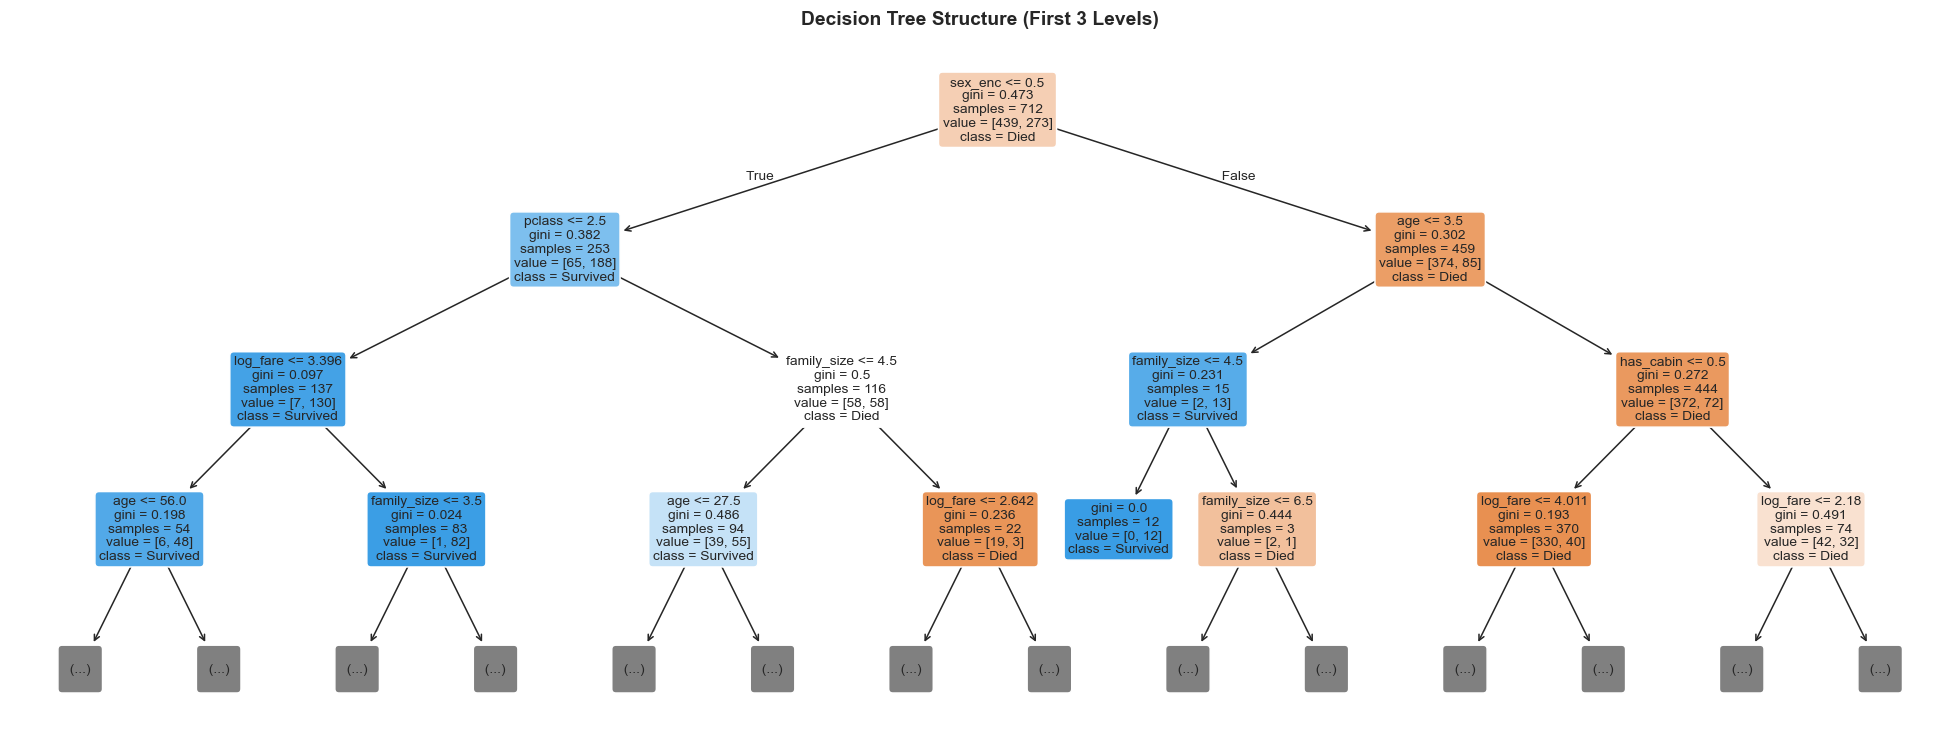

In [111]:
# Visualise the tree structure (pruned to depth 3 for readability)
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_base, max_depth=3, feature_names=FEATURES,
           class_names=['Died', 'Survived'],
           filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision Tree Structure (First 3 Levels)', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### Decision Tree Model Analysis

<div dir="rtl" align="right">
<p>
الـ <code>Decision Tree</code> بيحقق أداء قريب من الـ <code>Logistic Regression</code>. رسم الـ <code>feature importances</code> بيأكد إن <code>sex_enc</code> هو أهم <code>split criterion</code> — وده متفق مع اللي لقيناه في الـ <code>EDA</code> والـ <code>LR</code>.
</p>
<p>
رسم شجرة القرارات بيوضح طريقة عمل الموديل: أول <code>split</code> هو على <code>sex_enc</code>، وده بيقسم الركاب لمجموعتين مختلفتين جداً من حيث احتمال النجاة. بعد كده، كل فرع بيستخدم <code>pclass</code> و <code>log_fare</code> عشان يحسن التنبؤ داخل كل مجموعة.
</p>
<p>
الفرق بين <code>train</code> و <code>test accuracy</code> أكبر شوية من الـ <code>LR</code> — وده طبيعي لأن الـ <code>Decision Tree</code> موديل <strong><code>high-variance</code></strong> بطبيعته، وبيميل للـ <code>overfit</code> لو الـ <code>depth</code> مش محدود.
</p>
</div>


## 9. Final Models Comparison


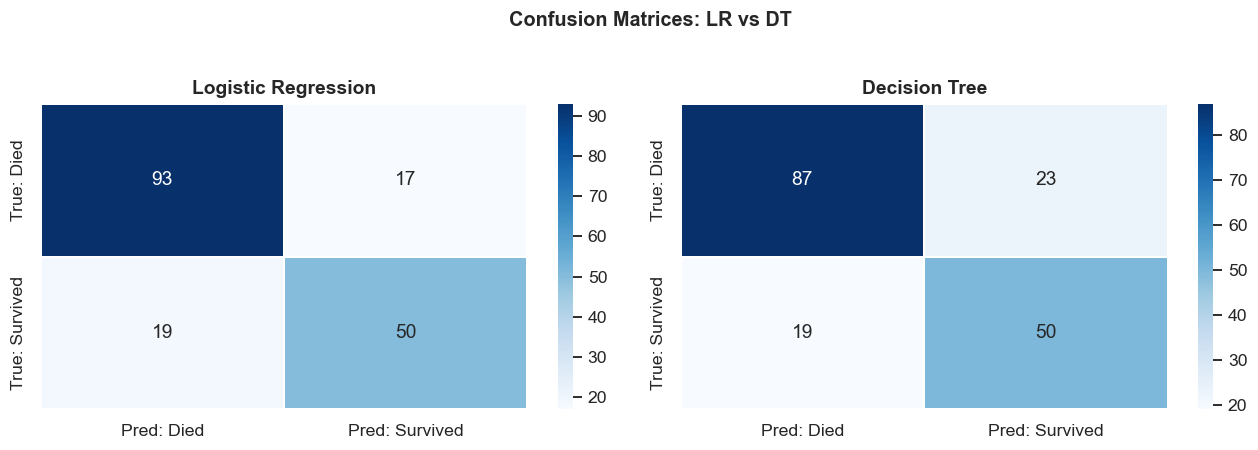

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

combos = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
]

for ax, (title, y_pred) in zip(axes, combos):
    plot_confusion_matrix(ax, y_test, y_pred, title)

plt.suptitle('Confusion Matrices: LR vs DT', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [113]:
summary_data = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy' : [accuracy_score(y_test,  y_pred_lr),  accuracy_score(y_test,  y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred_lr),  precision_score(y_test, y_pred_dt)],
    'Recall'   : [recall_score(y_test,    y_pred_lr),  recall_score(y_test,    y_pred_dt)],
    'F1-Score' : [f1_score(y_test,        y_pred_lr),  f1_score(y_test,        y_pred_dt)],
}

summary_df = pd.DataFrame(summary_data).set_index('Model')
print('Model Comparison:')
print(summary_df.round(4).to_string())


Model Comparison:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7989     0.7463  0.7246    0.7353
Decision Tree          0.7654     0.6849  0.7246    0.7042


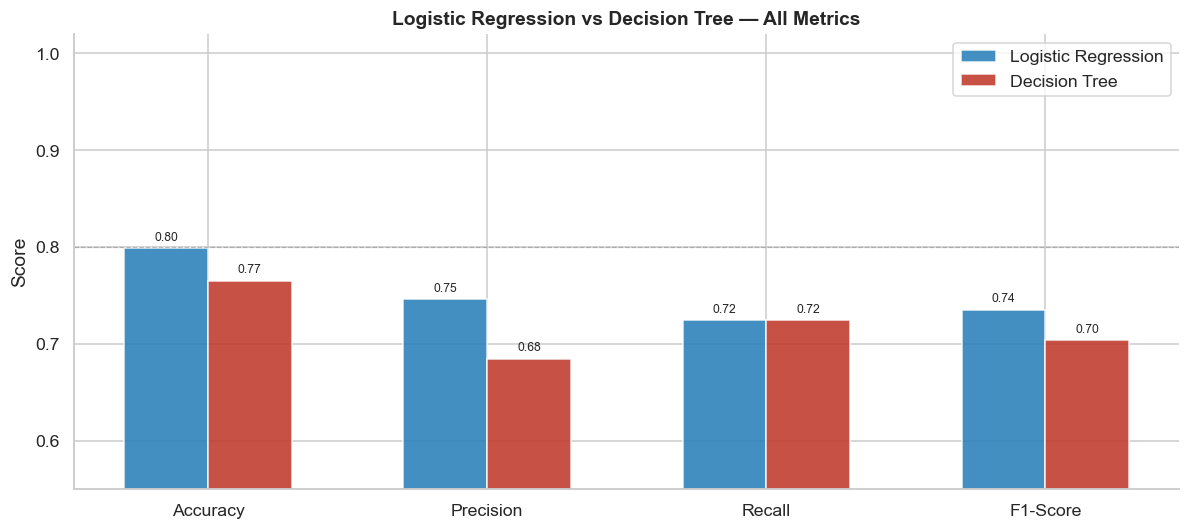

In [114]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_list = summary_df.index.tolist()
x          = np.arange(len(metrics))
width      = 0.30
palette    = ['#2980b9', '#c0392b']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model_name, color) in enumerate(zip(model_list, palette)):
    vals = [summary_df.loc[model_name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width,
                  label=model_name, color=color, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.55, 1.02)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs Decision Tree — All Metrics', fontweight='bold')
ax.legend()
ax.axhline(0.80, color='gray', ls='--', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


## 10. Joblib Saving

### Why Save the Preprocessing Objects?

<div dir="rtl" align="right">
<p>
الـ <code>StandardScaler</code> اتعلم من الـ <code>training data</code> — حفظ الـ <code>mean</code> والـ <code>std</code> لكل <code>feature</code>. لما بنيجي نعمل <code>prediction</code> على بيانات جديدة، لازم نطبق نفس الـ <code>transformation</code> بنفس القيم اللي اتعلمها. لو عملنا <code>scaler</code> جديد على الـ <code>production data</code>، هيجيب بأرقام مختلفة وده هيخرب النتائج.
</p>
<p>
كمان بنحفظ قائمة الـ <code>features</code> بالترتيب الصح عشان الـ <code>app</code> يبني الـ <code>input vector</code> بنفس الشكل اللي الموديل اتدرب عليه بالظبط — أي اختلاف في الترتيب ممكن يعطي نتائج غلط.
</p>
</div>


In [115]:
# Save Logistic Regression model
joblib.dump(lr_base, 'logistic_model.pkl')
print('Saved: logistic_model.pkl')

# Save Decision Tree model
joblib.dump(dt_base, 'decision_tree_model.pkl')
print('Saved: decision_tree_model.pkl')

# Save the scaler — required when loading the LR model for inference
joblib.dump(scaler, 'titanic_scaler.pkl')
print('Saved: titanic_scaler.pkl')

# Save the feature list to enforce correct column order at inference time
joblib.dump(FEATURES, 'titanic_features.pkl')
print('Saved: titanic_features.pkl')

print('\nAll artifacts saved successfully.')
print(f'Features: {FEATURES}')


Saved: logistic_model.pkl
Saved: decision_tree_model.pkl
Saved: titanic_scaler.pkl
Saved: titanic_features.pkl

All artifacts saved successfully.
Features: ['pclass', 'sex_enc', 'age', 'log_fare', 'has_cabin', 'age_was_missing', 'alone_enc', 'is_child', 'family_size', 'emb_Q', 'emb_S']


In [116]:
# Verification — reload both models and confirm predictions match
loaded_lr  = joblib.load('logistic_model.pkl')
loaded_dt  = joblib.load('decision_tree_model.pkl')
loaded_sc  = joblib.load('titanic_scaler.pkl')
loaded_ft  = joblib.load('titanic_features.pkl')

# LR needs scaling
X_check_lr = loaded_sc.transform(X_test[loaded_ft])
match_lr   = (loaded_lr.predict(X_check_lr) == y_pred_lr).all()

# DT does not need scaling
X_check_dt = X_test[loaded_ft]
match_dt   = (loaded_dt.predict(X_check_dt) == y_pred_dt).all()

print(f'LR  — predictions match: {match_lr}  | accuracy: {accuracy_score(y_test, loaded_lr.predict(X_check_lr)):.4f}')
print(f'DT  — predictions match: {match_dt}  | accuracy: {accuracy_score(y_test, loaded_dt.predict(X_check_dt)):.4f}')


LR  — predictions match: True  | accuracy: 0.7989
DT  — predictions match: True  | accuracy: 0.7654


## 11. Final Conclusions

<div dir="rtl" align="right">

<h3>أهم insights من الـ EDA</h3>
<p>التحليل الاستكشافي كشف عن <code>patterns</code> واضحة ومتسقة:</p>
<ul>
  <li><strong><code>Sex</code></strong> هي أقوى <code>feature</code> منفردة — نسبة نجاة الإناث (<code>~74%</code>) تفوق الذكور (<code>~19%</code>) بفرق ضخم.</li>
  <li><strong><code>Pclass</code></strong> هي ثاني أقوى <code>feature</code>. التفاعل بين الجنس والدرجة قوي جداً: إناث الدرجة الأولى نجوا بـ <code>~97%</code>، وذكور الدرجة التالتة بـ <code>~14%</code> فقط.</li>
  <li><strong><code>Age</code></strong> علاقته غير خطية. الأطفال (<code>&lt; 13</code>) الأعلى نجاةً؛ كبار السن الأقل. العمر الخام أضعف من الـ <code>is_child flag</code>.</li>
  <li><strong><code>Fare</code></strong> بعد الـ <code>log transformation</code>، بيوضح فصل واضح بين الناجين والمتوفين.</li>
  <li><strong><code>Family size</code></strong> بيكشف شكل <code>U</code> — عيلات صغيرة أفضل، مسافرين لوحدهم وعيلات كبيرة الأسوأ.</li>
  <li><strong><code>Embarked</code></strong> هو <code>proxy</code> لتركيبة الدرجات مش عامل مستقل.</li>
</ul>

<hr>

<h3>مقارنة الموديلين</h3>

<p><strong>Logistic Regression:</strong></p>
<ul>
  <li>موديل خطي مستقر — الفرق بين <code>train</code> و <code>test</code> صغير جداً، مما يدل على <code>low variance</code>.</li>
  <li>قابل للتفسير بشكل مباشر — كل <code>coefficient</code> بيوضح تأثير الـ <code>feature</code> على احتمال النجاة.</li>
  <li>بيستفيد من الـ <code>scaling</code> والـ <code>log transformation</code> لأنه حساس لمقياس الـ <code>features</code>.</li>
  <li>ممكن يفوته بعض العلاقات غير الخطية زي تفاعل <code>sex × pclass</code>.</li>
</ul>

<p><strong>Decision Tree:</strong></p>
<ul>
  <li>بيلتقط العلاقات غير الخطية بشكل طبيعي — أول <code>split</code> هو <code>sex_enc</code>، وبعدين <code>pclass</code> و <code>fare</code>.</li>
  <li>قابل للتفسير بصرياً — شجرة القرارات بتشرح كل قرار بلغة بسيطة.</li>
  <li>موديل <code>high-variance</code> — الفجوة بين <code>train</code> و <code>test</code> أكبر من الـ <code>LR</code>.</li>
  <li>مش محتاج <code>feature scaling</code>.</li>
</ul>

<hr>

<h3>Best Model</h3>
<p>
المودلين بيقدموا أداء متقارب على الـ <code>test set</code>. الاختيار بين الاتنين بيعتمد على الأولوية:
</p>
<ul>
  <li>لو الأولوية <strong>الاستقرار والتفسير الإحصائي</strong>: <strong>Logistic Regression</strong> هو الأنسب — الـ <code>train-test gap</code> أصغر والـ <code>coefficients</code> قابلة للقراءة مباشرة.</li>
  <li>لو الأولوية <strong>التفسير البصري والعلاقات غير الخطية</strong>: <strong>Decision Tree</strong> أوضح — شجرة القرارات سهلة الشرح لأي حد.</li>
</ul>

<hr>

<h3>تحسينات مستقبلية ممكنة</h3>
<ul>
  <li><strong>Interaction features</strong>: عمل <code>sex_enc × pclass</code> كـ <code>feature</code> مباشرة هيدي الـ <code>LR</code> إمكانية التقاط التفاعل ده.</li>
  <li><strong>Fare per person</strong>: قسمة الأجرة على حجم العيلة بيدي مقياس أدق للثروة.</li>
  <li><strong>Hyperparameter tuning</strong>: تجربة قيم مختلفة لـ <code>C</code> في الـ <code>LR</code> أو <code>max_depth</code> في الـ <code>DT</code> ممكن يحسن الأداء.</li>
  <li><strong>Cross-validation</strong>: استخدام <code>StratifiedKFold</code> بيدي تقدير أكثر موثوقية من الـ <code>single split</code>.</li>
</ul>

</div>
